📊 Blocklängen:
  Block n=-1: 372 Samples, 9300.0 ms
  Block n=0: 365 Samples, 9125.0 ms
  Block n=1: 210 Samples, 5250.0 ms

🧱 Mega-Block: 445 Samples, 11125.0 ms

🎚️ Resampled: 490612 Samples, 11124.99 ms

🔊 Hochpassfilter angewendet: > 1 Hz

✂️ Nach Zuschneiden: 411232 Samples = 9324.99 ms

💾 WAV gespeichert als: block_0004_processed.wav

📊 WAV-Daten:
  Samplerate: 44100 Hz
  Samples:    411232
  Dauer:      9324.99 ms
  Peak-Level: 137588.942


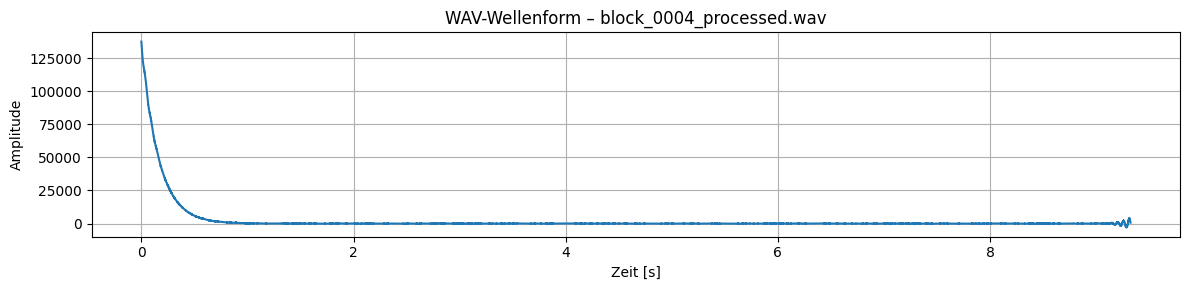

In [8]:
# All steps together (process mseed blocks to wav blocks ready for overlap crossfading)

import obspy
import numpy as np
import resampy
from scipy.signal import butter, lfilter
import soundfile as sf
import matplotlib.pyplot as plt

# -------------------------
# 🔧 Konfiguration
# -------------------------
mseed_files = [
    #"block_0003_20250523_112022.mseed",  # n = -1
    #"block_0004_20250523_112049.mseed",  # n =  0
    #"block_0005_20250523_112115.mseed"   # n = +1
    "block_0313_SALP_20250618_140554_40_372.mseed",
    "block_0314_SALP_20250618_140603_40_365.mseed",
    "block_0315_SALP_20250618_140608_40_210.mseed"
]
x_ms = 1000       # Verlängerung vorne/hinten (ms)
y_ms = 100        # Crossfade-Overlap je Seite (ms)
cutoff = 1     # Hochpass-Grenzfrequenz (Hz)
order = 1        # Filterordnung
target_sr = 44100  # Zielsamplerate (Hz)

# -------------------------
# Schritt 1: Blöcke laden & Längen ausgeben
# -------------------------
traces = [obspy.read(f)[0] for f in mseed_files]

print("📊 Blocklängen:")
for i, tr in enumerate(traces):
    samples = len(tr.data)
    duration_ms = samples / tr.stats.sampling_rate * 1000
    print(f"  Block n={i - 1}: {samples} Samples, {duration_ms:.1f} ms")

# -------------------------
# Schritt 2: Mega-Block zusammensetzen
# -------------------------
sr = traces[1].stats.sampling_rate  # Originalrate (z. B. 100 Hz)
samples_x = int((x_ms / 1000) * sr)

segment_prev = traces[0].data[-samples_x:]
segment_main = traces[1].data
segment_next = traces[2].data[:samples_x]

mega_block = np.concatenate([segment_prev, segment_main, segment_next])
print(f"\n🧱 Mega-Block: {len(mega_block)} Samples, {len(mega_block)/sr*1000:.1f} ms")

# -------------------------
# Schritt 3: Resampling
# -------------------------
mega_block_resampled = resampy.resample(mega_block, sr_orig=sr, sr_new=target_sr)
print(f"\n🎚️ Resampled: {len(mega_block_resampled)} Samples, {len(mega_block_resampled)/target_sr*1000:.2f} ms")

# -------------------------
# Schritt 4: Hochpassfilter
# -------------------------
def butter_highpass(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    norm_cutoff = cutoff / nyq
    b, a = butter(order, norm_cutoff, btype='high', analog=False)
    return lfilter(b, a, data)

mega_block_filtered = butter_highpass(mega_block_resampled, cutoff, fs=target_sr, order=order)
print(f"\n🔊 Hochpassfilter angewendet: > {cutoff} Hz")

# -------------------------
# Schritt 5: Zuschneiden (x - y ms)
# -------------------------
cut_ms = x_ms - y_ms
cut_samples = int((cut_ms / 1000) * target_sr)
block_processed = mega_block_filtered[cut_samples:-cut_samples]

duration_ms_processed = len(block_processed) / target_sr * 1000
print(f"\n✂️ Nach Zuschneiden: {len(block_processed)} Samples = {duration_ms_processed:.2f} ms")

# -------------------------
# Schritt 6: Speichern als WAV + Plot + Infos
# -------------------------
# Normalisieren
# block_normalized = block_processed / np.max(np.abs(block_processed))

# Speichern
wav_filename = "block_0004_processed.wav"
sf.write(wav_filename, block_processed, samplerate=target_sr)
print(f"\n💾 WAV gespeichert als: {wav_filename}")

# Infos
samples = len(block_processed)
duration_ms = samples / target_sr * 1000
peak = np.max(np.abs(block_processed))

print("\n📊 WAV-Daten:")
print(f"  Samplerate: {target_sr} Hz")
print(f"  Samples:    {samples}")
print(f"  Dauer:      {duration_ms:.2f} ms")
print(f"  Peak-Level: {peak:.3f}")

# Plot
time_axis = np.linspace(0, duration_ms / 1000, num=samples)
plt.figure(figsize=(12, 3))
plt.plot(time_axis, block_processed)
plt.title(f"WAV-Wellenform – {wav_filename}")
plt.xlabel("Zeit [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()


In [2]:
# All steps as function

import obspy
import numpy as np
import resampy
from scipy.signal import butter, lfilter
import soundfile as sf
import matplotlib.pyplot as plt

def butter_highpass(data, cutoff, fs, order=1):
    nyq = 0.5 * fs
    norm_cutoff = cutoff / nyq
    b, a = butter(order, norm_cutoff, btype='high', analog=False)
    return lfilter(b, a, data)

def process_block(n, mseed_files, x_ms, y_ms, target_sr, cutoff_hz, out_wav_name):
    # -------------------------
    # Schritt 1: Lade 3 Blöcke n-1, n, n+1
    # -------------------------
    if n < 1 or n > len(mseed_files) - 2:
        raise ValueError("Index n muss >=1 und <=len-2 sein")

    trace_prev = obspy.read(mseed_files[n - 1])[0]
    trace_main = obspy.read(mseed_files[n])[0]
    trace_next = obspy.read(mseed_files[n + 1])[0]

    print("📊 Blocklängen:")
    for label, tr in zip(["n-1", "n", "n+1"], [trace_prev, trace_main, trace_next]):
        samples = len(tr.data)
        dur = samples / tr.stats.sampling_rate * 1000
        print(f"  Block {label}: {samples} Samples, {dur:.1f} ms")

    # -------------------------
    # Schritt 2: Mega-Block zusammenbauen
    # -------------------------
    sr = trace_main.stats.sampling_rate
    samples_x = int((x_ms / 1000) * sr)

    segment_prev = trace_prev.data[-samples_x:]
    segment_main = trace_main.data
    segment_next = trace_next.data[:samples_x]

    mega_block = np.concatenate([segment_prev, segment_main, segment_next])
    print(f"\n🧱 Mega-Block: {len(mega_block)} Samples, {len(mega_block)/sr*1000:.1f} ms")

    # -------------------------
    # Schritt 3: Resampling
    # -------------------------
    resampled = resampy.resample(mega_block, sr_orig=sr, sr_new=target_sr)
    print(f"\n🎚️ Resampled: {len(resampled)} Samples, {len(resampled)/target_sr*1000:.2f} ms")

    # -------------------------
    # Schritt 4: Hochpassfilter
    # -------------------------
    filtered = butter_highpass(resampled, cutoff_hz, target_sr)
    print(f"\n🔊 Hochpassfilter: > {cutoff_hz} Hz")

    # -------------------------
    # Schritt 5: Zuschneiden
    # -------------------------
    cut_ms = x_ms - y_ms
    cut_samples = int((cut_ms / 1000) * target_sr)
    block_processed = filtered[cut_samples:-cut_samples]
    dur_ms = len(block_processed) / target_sr * 1000
    print(f"\n✂️ Nach Zuschneiden: {len(block_processed)} Samples = {dur_ms:.2f} ms")

    # -------------------------
    # Schritt 7: WAV speichern + Plot + Info
    # -------------------------
    block_normalized = block_processed / np.max(np.abs(block_processed))
    sf.write(out_wav_name, block_normalized, samplerate=target_sr)
    print(f"\n💾 WAV gespeichert als: {out_wav_name}")

    print("\n📊 WAV-Daten:")
    print(f"  Samplerate: {target_sr} Hz")
    print(f"  Samples:    {len(block_normalized)}")
    print(f"  Dauer:      {dur_ms:.2f} ms")
    print(f"  Peak-Level: {np.max(np.abs(block_normalized)):.3f}")

    time_axis = np.linspace(0, dur_ms / 1000, num=len(block_normalized))
    plt.figure(figsize=(12, 3))
    plt.plot(time_axis, block_normalized)
    plt.title(f"WAV-Wellenform – {out_wav_name}")
    plt.xlabel("Zeit [s]")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Gefundene .mseed-Dateien: 15
Verarbeite Block 1: block_0276_KBU_20250618_184523_20_210.mseed
📊 Blocklängen:
  Block n-1: 214 Samples, 10700.0 ms
  Block n: 210 Samples, 10500.0 ms
  Block n+1: 211 Samples, 10550.0 ms

🧱 Mega-Block: 250 Samples, 12500.0 ms

🎚️ Resampled: 551250 Samples, 12500.00 ms

🔊 Hochpassfilter: > 1 Hz

✂️ Nach Zuschneiden: 471870 Samples = 10700.00 ms

💾 WAV gespeichert als: wav/block_0276_KBU_20250618_184523_20_210_processed.wav

📊 WAV-Daten:
  Samplerate: 44100 Hz
  Samples:    471870
  Dauer:      10700.00 ms
  Peak-Level: 1.000


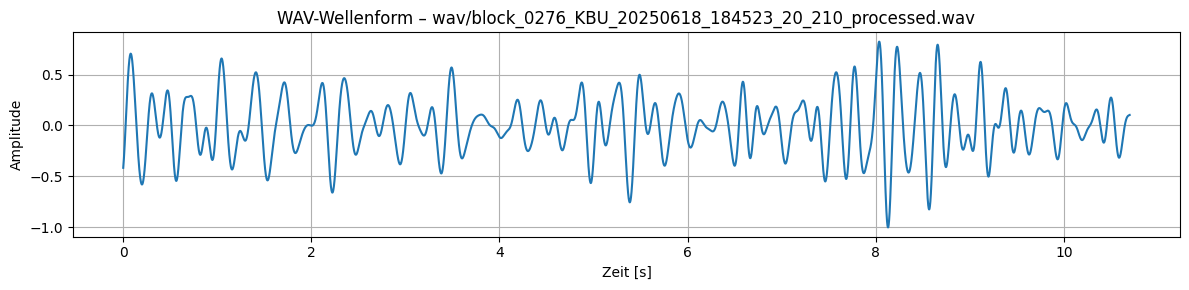

Verarbeite Block 2: block_0277_KBU_20250618_184533_20_211.mseed
📊 Blocklängen:
  Block n-1: 210 Samples, 10500.0 ms
  Block n: 211 Samples, 10550.0 ms
  Block n+1: 209 Samples, 10450.0 ms

🧱 Mega-Block: 251 Samples, 12550.0 ms

🎚️ Resampled: 553455 Samples, 12550.00 ms

🔊 Hochpassfilter: > 1 Hz

✂️ Nach Zuschneiden: 474075 Samples = 10750.00 ms

💾 WAV gespeichert als: wav/block_0277_KBU_20250618_184533_20_211_processed.wav

📊 WAV-Daten:
  Samplerate: 44100 Hz
  Samples:    474075
  Dauer:      10750.00 ms
  Peak-Level: 1.000


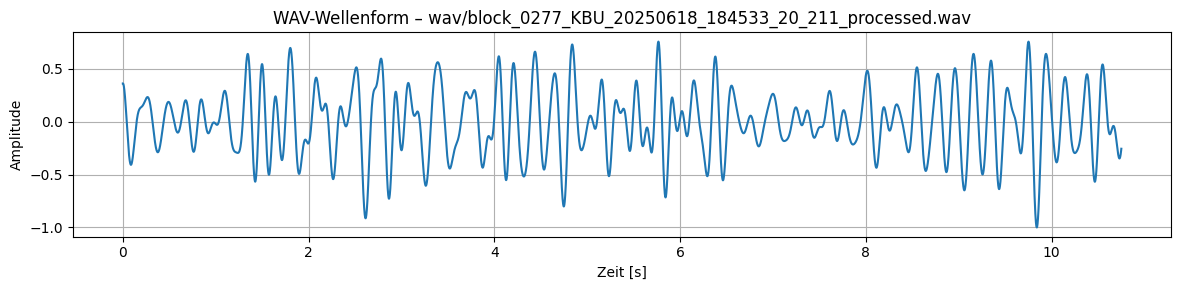

Verarbeite Block 3: block_0278_KBU_20250618_184544_20_209.mseed
📊 Blocklängen:
  Block n-1: 211 Samples, 10550.0 ms
  Block n: 209 Samples, 10450.0 ms
  Block n+1: 207 Samples, 10350.0 ms

🧱 Mega-Block: 249 Samples, 12450.0 ms

🎚️ Resampled: 549045 Samples, 12450.00 ms

🔊 Hochpassfilter: > 1 Hz

✂️ Nach Zuschneiden: 469665 Samples = 10650.00 ms

💾 WAV gespeichert als: wav/block_0278_KBU_20250618_184544_20_209_processed.wav

📊 WAV-Daten:
  Samplerate: 44100 Hz
  Samples:    469665
  Dauer:      10650.00 ms
  Peak-Level: 1.000


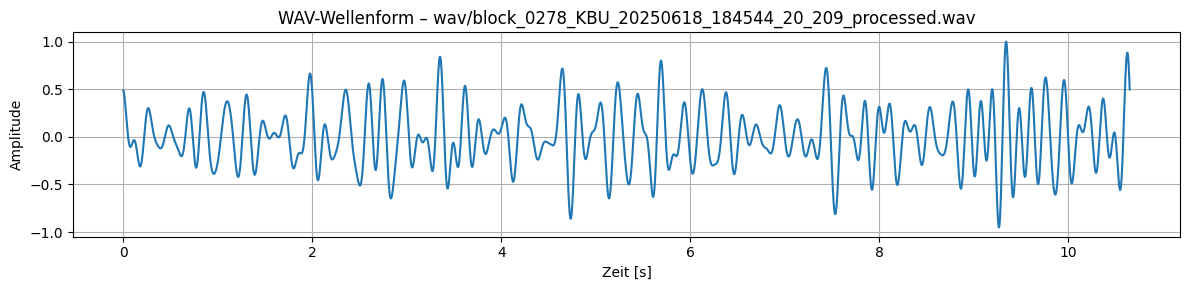

Verarbeite Block 4: block_0279_KBU_20250618_184554_20_207.mseed
📊 Blocklängen:
  Block n-1: 209 Samples, 10450.0 ms
  Block n: 207 Samples, 10350.0 ms
  Block n+1: 207 Samples, 10350.0 ms

🧱 Mega-Block: 247 Samples, 12350.0 ms

🎚️ Resampled: 544635 Samples, 12350.00 ms

🔊 Hochpassfilter: > 1 Hz

✂️ Nach Zuschneiden: 465255 Samples = 10550.00 ms

💾 WAV gespeichert als: wav/block_0279_KBU_20250618_184554_20_207_processed.wav

📊 WAV-Daten:
  Samplerate: 44100 Hz
  Samples:    465255
  Dauer:      10550.00 ms
  Peak-Level: 1.000


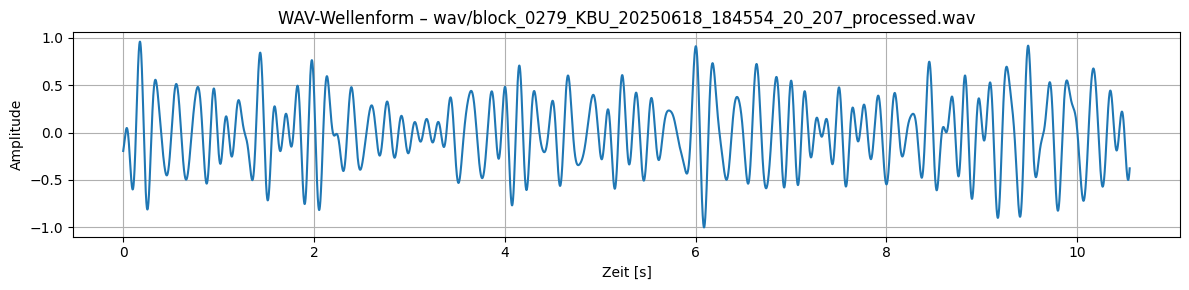

Verarbeite Block 5: block_0280_KBU_20250618_184604_20_207.mseed
📊 Blocklängen:
  Block n-1: 207 Samples, 10350.0 ms
  Block n: 207 Samples, 10350.0 ms
  Block n+1: 206 Samples, 10300.0 ms

🧱 Mega-Block: 247 Samples, 12350.0 ms

🎚️ Resampled: 544635 Samples, 12350.00 ms

🔊 Hochpassfilter: > 1 Hz

✂️ Nach Zuschneiden: 465255 Samples = 10550.00 ms

💾 WAV gespeichert als: wav/block_0280_KBU_20250618_184604_20_207_processed.wav

📊 WAV-Daten:
  Samplerate: 44100 Hz
  Samples:    465255
  Dauer:      10550.00 ms
  Peak-Level: 1.000


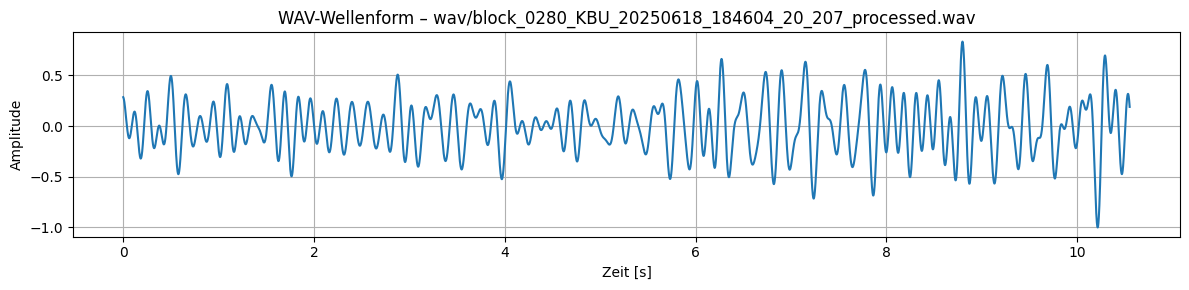

Verarbeite Block 6: block_0281_KBU_20250618_184615_20_206.mseed
📊 Blocklängen:
  Block n-1: 207 Samples, 10350.0 ms
  Block n: 206 Samples, 10300.0 ms
  Block n+1: 206 Samples, 10300.0 ms

🧱 Mega-Block: 246 Samples, 12300.0 ms

🎚️ Resampled: 542430 Samples, 12300.00 ms

🔊 Hochpassfilter: > 1 Hz

✂️ Nach Zuschneiden: 463050 Samples = 10500.00 ms

💾 WAV gespeichert als: wav/block_0281_KBU_20250618_184615_20_206_processed.wav

📊 WAV-Daten:
  Samplerate: 44100 Hz
  Samples:    463050
  Dauer:      10500.00 ms
  Peak-Level: 1.000


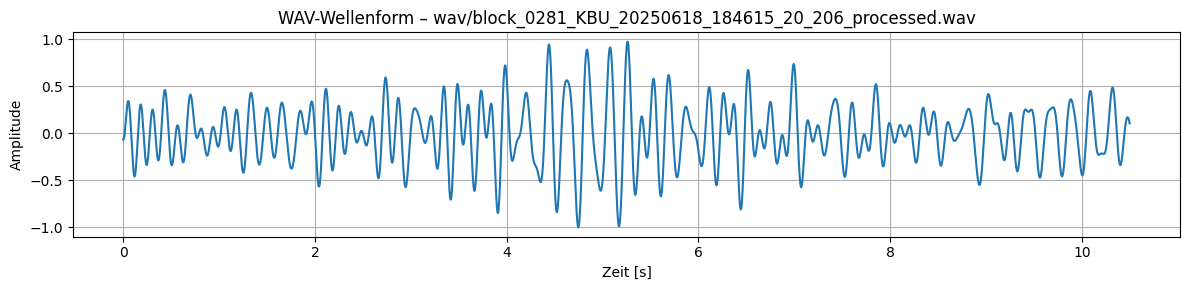

Verarbeite Block 7: block_0282_KBU_20250618_184625_20_206.mseed
📊 Blocklängen:
  Block n-1: 206 Samples, 10300.0 ms
  Block n: 206 Samples, 10300.0 ms
  Block n+1: 207 Samples, 10350.0 ms

🧱 Mega-Block: 246 Samples, 12300.0 ms

🎚️ Resampled: 542430 Samples, 12300.00 ms

🔊 Hochpassfilter: > 1 Hz

✂️ Nach Zuschneiden: 463050 Samples = 10500.00 ms

💾 WAV gespeichert als: wav/block_0282_KBU_20250618_184625_20_206_processed.wav

📊 WAV-Daten:
  Samplerate: 44100 Hz
  Samples:    463050
  Dauer:      10500.00 ms
  Peak-Level: 1.000


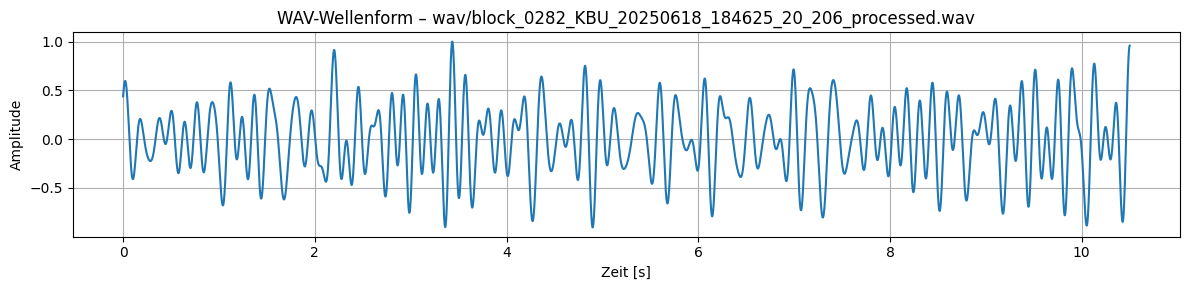

Verarbeite Block 8: block_0283_KBU_20250618_184635_20_207.mseed
📊 Blocklängen:
  Block n-1: 206 Samples, 10300.0 ms
  Block n: 207 Samples, 10350.0 ms
  Block n+1: 206 Samples, 10300.0 ms

🧱 Mega-Block: 247 Samples, 12350.0 ms

🎚️ Resampled: 544635 Samples, 12350.00 ms

🔊 Hochpassfilter: > 1 Hz

✂️ Nach Zuschneiden: 465255 Samples = 10550.00 ms

💾 WAV gespeichert als: wav/block_0283_KBU_20250618_184635_20_207_processed.wav

📊 WAV-Daten:
  Samplerate: 44100 Hz
  Samples:    465255
  Dauer:      10550.00 ms
  Peak-Level: 1.000


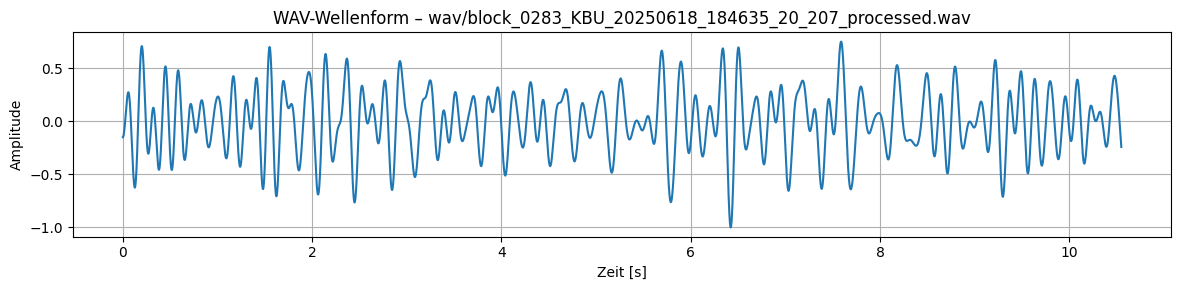

Verarbeite Block 9: block_0284_KBU_20250618_184646_20_206.mseed
📊 Blocklängen:
  Block n-1: 207 Samples, 10350.0 ms
  Block n: 206 Samples, 10300.0 ms
  Block n+1: 207 Samples, 10350.0 ms

🧱 Mega-Block: 246 Samples, 12300.0 ms

🎚️ Resampled: 542430 Samples, 12300.00 ms

🔊 Hochpassfilter: > 1 Hz

✂️ Nach Zuschneiden: 463050 Samples = 10500.00 ms

💾 WAV gespeichert als: wav/block_0284_KBU_20250618_184646_20_206_processed.wav

📊 WAV-Daten:
  Samplerate: 44100 Hz
  Samples:    463050
  Dauer:      10500.00 ms
  Peak-Level: 1.000


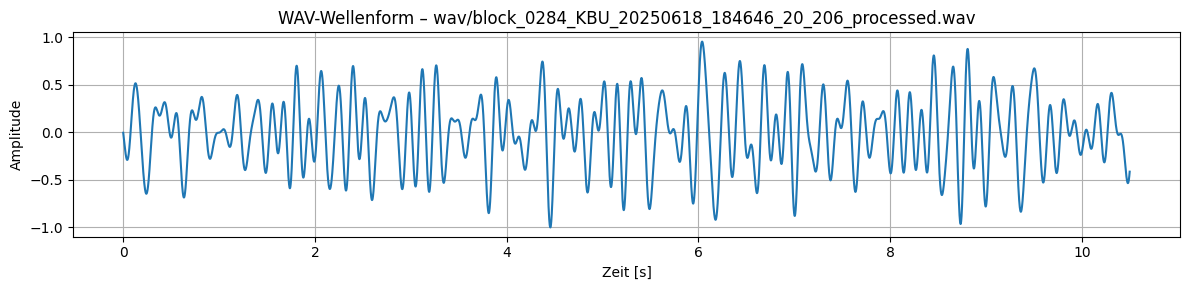

Verarbeite Block 10: block_0285_KBU_20250618_184656_20_207.mseed
📊 Blocklängen:
  Block n-1: 206 Samples, 10300.0 ms
  Block n: 207 Samples, 10350.0 ms
  Block n+1: 207 Samples, 10350.0 ms

🧱 Mega-Block: 247 Samples, 12350.0 ms

🎚️ Resampled: 544635 Samples, 12350.00 ms

🔊 Hochpassfilter: > 1 Hz

✂️ Nach Zuschneiden: 465255 Samples = 10550.00 ms

💾 WAV gespeichert als: wav/block_0285_KBU_20250618_184656_20_207_processed.wav

📊 WAV-Daten:
  Samplerate: 44100 Hz
  Samples:    465255
  Dauer:      10550.00 ms
  Peak-Level: 1.000


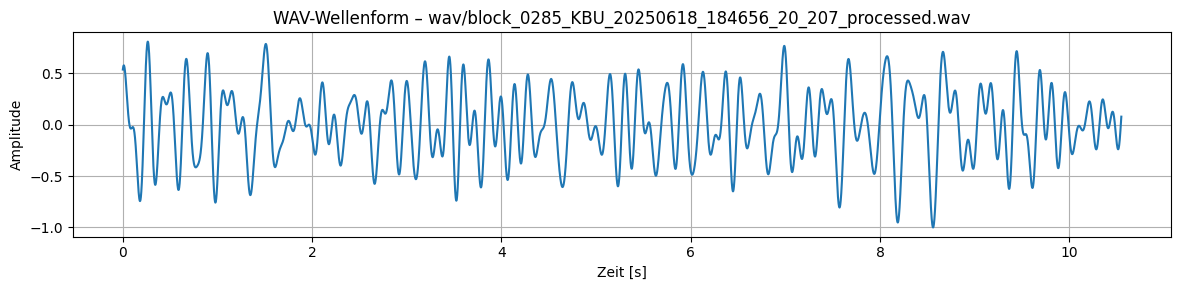

Verarbeite Block 11: block_0286_KBU_20250618_184707_20_207.mseed
📊 Blocklängen:
  Block n-1: 207 Samples, 10350.0 ms
  Block n: 207 Samples, 10350.0 ms
  Block n+1: 207 Samples, 10350.0 ms

🧱 Mega-Block: 247 Samples, 12350.0 ms

🎚️ Resampled: 544635 Samples, 12350.00 ms

🔊 Hochpassfilter: > 1 Hz

✂️ Nach Zuschneiden: 465255 Samples = 10550.00 ms

💾 WAV gespeichert als: wav/block_0286_KBU_20250618_184707_20_207_processed.wav

📊 WAV-Daten:
  Samplerate: 44100 Hz
  Samples:    465255
  Dauer:      10550.00 ms
  Peak-Level: 1.000


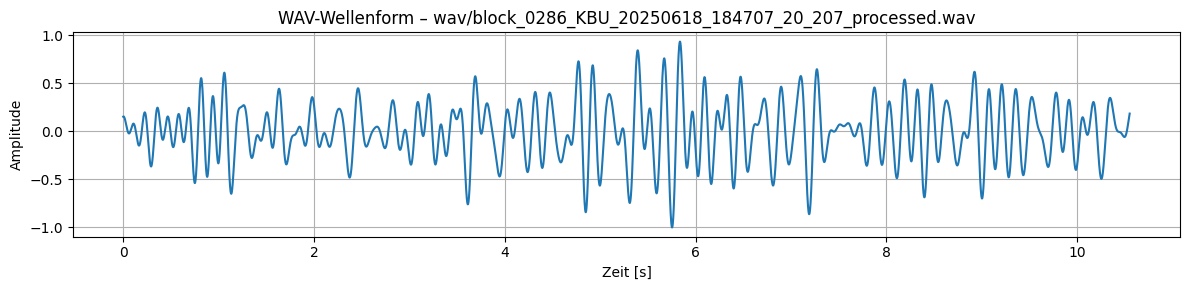

Verarbeite Block 12: block_0287_KBU_20250618_184717_20_207.mseed
📊 Blocklängen:
  Block n-1: 207 Samples, 10350.0 ms
  Block n: 207 Samples, 10350.0 ms
  Block n+1: 207 Samples, 10350.0 ms

🧱 Mega-Block: 247 Samples, 12350.0 ms

🎚️ Resampled: 544635 Samples, 12350.00 ms

🔊 Hochpassfilter: > 1 Hz

✂️ Nach Zuschneiden: 465255 Samples = 10550.00 ms

💾 WAV gespeichert als: wav/block_0287_KBU_20250618_184717_20_207_processed.wav

📊 WAV-Daten:
  Samplerate: 44100 Hz
  Samples:    465255
  Dauer:      10550.00 ms
  Peak-Level: 1.000


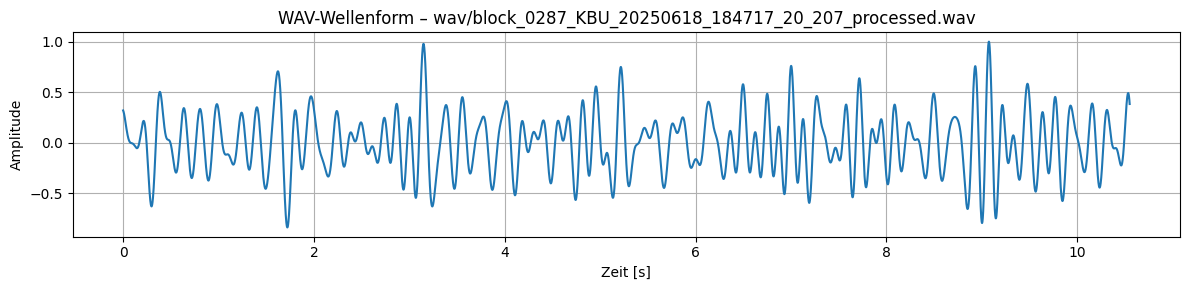

Verarbeite Block 13: block_0288_KBU_20250618_184727_20_207.mseed
📊 Blocklängen:
  Block n-1: 207 Samples, 10350.0 ms
  Block n: 207 Samples, 10350.0 ms
  Block n+1: 209 Samples, 10450.0 ms

🧱 Mega-Block: 247 Samples, 12350.0 ms

🎚️ Resampled: 544635 Samples, 12350.00 ms

🔊 Hochpassfilter: > 1 Hz

✂️ Nach Zuschneiden: 465255 Samples = 10550.00 ms

💾 WAV gespeichert als: wav/block_0288_KBU_20250618_184727_20_207_processed.wav

📊 WAV-Daten:
  Samplerate: 44100 Hz
  Samples:    465255
  Dauer:      10550.00 ms
  Peak-Level: 1.000


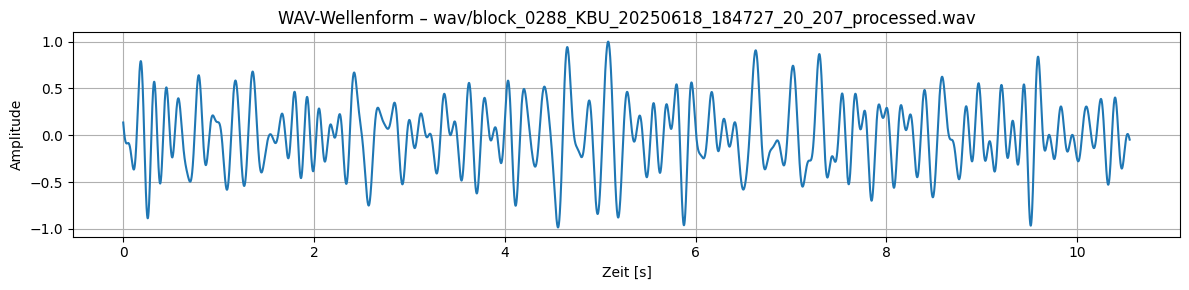

In [22]:
import os

# Ordnerpfade festlegen
mseed_folder = "raw1"
wav_folder = "wav"
os.makedirs(wav_folder, exist_ok=True)

# 🔁 WAV-Ordner leeren
for f in os.listdir(wav_folder):
    if f.endswith(".wav"):
        os.remove(os.path.join(wav_folder, f))

# Anzahl der zu verarbeitenden Blöcke (mind. 3 nötig)
num_blocks = 15

# Alle .mseed-Dateien aus dem Ordner holen und sortieren
mseed_files = sorted([
    os.path.join(mseed_folder, f)
    for f in os.listdir(mseed_folder)
    if f.endswith(".mseed")
])[:num_blocks]

print(f"Gefundene .mseed-Dateien: {len(mseed_files)}")

# Aufrufe mit Indizes innerhalb der gültigen Grenzen (1 <= n <= len(mseed_files) - 2)
for n in range(1, len(mseed_files) - 1):
    basename = os.path.basename(mseed_files[n]).replace(".mseed", "_processed.wav")
    outname = os.path.join(wav_folder, basename)
    print(f"Verarbeite Block {n}: {os.path.basename(mseed_files[n])}")
    try:
        process_block(
            n=n,
            mseed_files=mseed_files,
            x_ms=1000,
            y_ms=100,
            target_sr=44100,
            cutoff_hz=1,
            out_wav_name=outname
        )
    except Exception as e:
        print(f"⚠️ Fehler bei Block {n}: {e}")


In [7]:
# Crossfade as function {unusal overlap crossfading: the overlap y(ms) is added at the start and at the end of each block.
# so each crossfade runs for 2*y(ms) in total }

import soundfile as sf
import numpy as np

def crossfade_blocks(wav_files, y_ms, samplerate):
    """
    Fügt eine Liste von WAV-Dateien mit symmetrischem Crossfade zusammen.

    Args:
        wav_files (list of str): Liste der Pfade zu den WAV-Dateien (sortiert).
        y_ms (int): Crossfade-Bereich in Millisekunden (jeweils vorne & hinten).
        samplerate (int): Abtastrate der WAV-Dateien.

    Returns:
        np.ndarray: Einzeln kombiniertes Signal mit Crossfades.
    """
    y_samples = int((y_ms / 1000) * samplerate)

    # Alle WAVs laden
    blocks = [sf.read(f, dtype='float32')[0] for f in wav_files]
    if len(blocks) < 2:
        raise ValueError("Mindestens zwei Blöcke nötig für Crossfade.")

    # Initialisiere mit erstem Block
    combined = blocks[0]

    for i in range(1, len(blocks)):
        prev = combined[-y_samples:]
        next = blocks[i][:y_samples]

        fade_in = np.linspace(0, 1, y_samples)
        fade_out = 1 - fade_in
        blended = prev * fade_out + next * fade_in

        rest = blocks[i][y_samples:]
        combined = np.concatenate([combined[:-y_samples], blended, rest])

    return combined


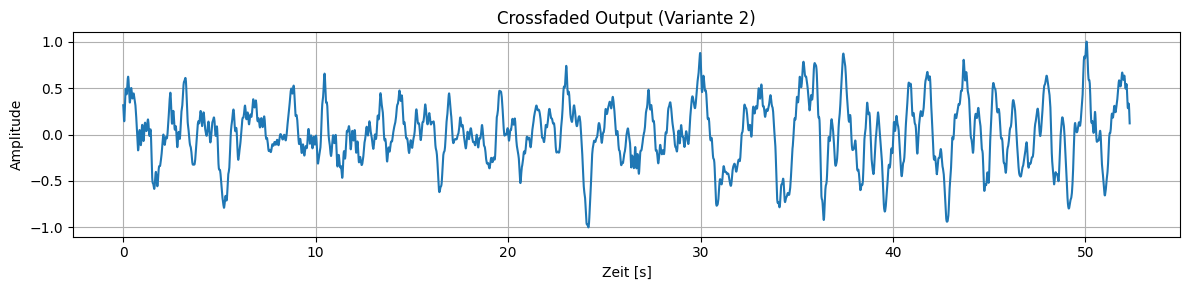

In [3]:
# Apply crossfade function

wav_files = [
    "block_0002_processed.wav",
    "block_0003_processed.wav",
    #"block_0004_processed.wav",
    #"block_0005_processed.wav"
]

# Anwenden
combined = crossfade_blocks(wav_files, y_ms=100, samplerate=44100)

# Speichern
sf.write("crossfaded_output.wav", combined, samplerate=44100)

# Plot optional
import matplotlib.pyplot as plt
t = np.linspace(0, len(combined)/44100, len(combined))
plt.figure(figsize=(12, 3))
plt.plot(t, combined)
plt.title("Crossfaded Output (Variante 2)")
plt.xlabel("Zeit [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()
